<a href="https://colab.research.google.com/github/Gunateja020/Data-Visualization/blob/main/DV_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install dash

In [8]:
import pandas as pd
import plotly.express as px
from geopy.geocoders import Nominatim
import time
import folium
import plotly.graph_objects as go
from IPython.display import display, HTML, IFrame, display
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import ipywidgets as widgets
import plotly.subplots as sp
import dash
from dash import Dash, dcc, html
from dash.dependencies import Input, Output
import warnings
warnings.filterwarnings("ignore")

In [9]:
df= pd.read_excel('Fury_Friends data set_4376.xlsx')

In [10]:
df.columns

Index(['Managers First Name', 'Managers Surname', 'Area', 'Pet', 'Units Sld',
       'Revenue', 'Cost', 'Profit', 'Date'],
      dtype='object')

In [11]:
df

,Managers First Name,Managers Surname,Area,Pet,Units Sld,Revenue,Cost,Profit,Date
0,Adam,Jones,Dudley,Cat,1118.0,5590.0,2459.6,3130.4,2020-11-01
1,Adam,Jones,Dudley,Cat,708.0,3540.0,1557.6,1982.4,2020-06-01
2,Adam,Jones,Dudley,Cat,1269.0,6345.0,2791.8,3553.2,2020-10-01
3,Adam,Jones,Dudley,Cat,1631.0,8155.0,3588.2,4566.8,2020-07-01
4,Adam,Jones,Dudley,Cat,2240.0,11200.0,4928.0,NaN,2020-02-01
...,...,...,...,...,...,...,...,...,...
996,Raj,Patel,Margate,Bird,NaN,9576.0,4389.0,NaN,2020-09-01
997,Raj,Patel,Margate,Bird,986.0,5916.0,2711.5,3204.5,2020-10-01
998,Raj,Patel,Margate,Bird,606.0,3636.0,1666.5,1969.5,2020-04-01
999,Raj,Patel,Margate,Bird,2460.0,14760.0,6765.0,7995.0,2020-07-01


In [12]:
df.isna().sum()

,0
Managers First Name,15
Managers Surname,16
Area,0
Pet,0
Units Sld,10
Revenue,13
Cost,7
Profit,6
Date,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Managers First Name  986 non-null    object        
 1   Managers Surname     985 non-null    object        
 2   Area                 1001 non-null   object        
 3   Pet                  1001 non-null   object        
 4   Units Sld            991 non-null    float64       
 5   Revenue              988 non-null    float64       
 6   Cost                 994 non-null    float64       
 7   Profit               995 non-null    float64       
 8   Date                 1001 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 70.5+ KB


In [14]:
# Define the columns you want unique values for
columns_of_interest = ["Managers First Name", "Managers Surname", "Area", "Pet"]

# Get unique values for selected columns
unique_values = {col: df[col].unique() for col in columns_of_interest}

# Print unique values
for col, values in unique_values.items():
    print(f"Unique values in '{col}': {values}\n")

Unique values in 'Managers First Name': ['Adam' 'Amanda' 'Bogdan' nan 'Nigella' 'Raj']

Unique values in 'Managers Surname': ['Jones' 'Brown' nan 'Black' 'Cocks' 'Patel']

Unique values in 'Area': ['Dudley' 'Manchester' 'Blackpool' 'Glasgow' 'Margate']

Unique values in 'Pet': ['Cat' 'Dog' 'Fish' 'Bird' 'Hampster' 'Rabbit']



In [15]:
result = df.groupby('Area').agg({
    'Managers First Name': lambda x: x.unique().tolist(),
    'Managers Surname': lambda x: x.unique().tolist()
}).reset_index()

print(result)

         Area Managers First Name Managers Surname
0   Blackpool       [Bogdan, nan]     [Black, nan]
1      Dudley         [Adam, nan]     [Jones, nan]
2     Glasgow      [Nigella, nan]     [Cocks, nan]
3  Manchester       [Amanda, nan]     [Brown, nan]
4     Margate          [Raj, nan]     [Patel, nan]


In [16]:
# Fill the "Managers First Name" column
df["Managers First Name"] = (
    df.groupby("Area")["Managers First Name"]
      .transform(lambda x: x.fillna(x.dropna().unique()[0]))
)

# Fill the "Managers Surname" column
df["Managers Surname"] = (
    df.groupby("Area")["Managers Surname"]
      .transform(lambda x: x.fillna(x.dropna().unique()[0]))
)

In [17]:
result1 = df.groupby('Area').agg({
    'Managers First Name': lambda x: x.unique().tolist(),
    'Managers Surname': lambda x: x.unique().tolist()
}).reset_index()

result1

,Area,Managers First Name,Managers Surname
0,Blackpool,[Bogdan],[Black]
1,Dudley,[Adam],[Jones]
2,Glasgow,[Nigella],[Cocks]
3,Manchester,[Amanda],[Brown]
4,Margate,[Raj],[Patel]


In [18]:
# Combine manager names to create a unique store identifier
df['Manager'] = df['Managers First Name'] + ' ' + df['Managers Surname']

In [19]:
# Fill 'Cost' where 'Revenue' and 'Profit' are available
mask_cost = df['Cost'].isna() & ~df['Revenue'].isna() & ~df['Profit'].isna()
df.loc[mask_cost, 'Cost'] = df.loc[mask_cost, 'Revenue'] - df.loc[mask_cost, 'Profit']

# Fill 'Profit' where 'Revenue' and 'Cost' are available
mask_profit = df['Profit'].isna() & ~df['Revenue'].isna() & ~df['Cost'].isna()
df.loc[mask_profit, 'Profit'] = df.loc[mask_profit, 'Revenue'] - df.loc[mask_profit, 'Cost']

# Fill remaining missing values with group medians
columns_to_fill = ['Cost', 'Profit', 'Revenue', 'Units Sld']
for col in columns_to_fill:
    # Calculate median within each 'Area' and 'Pet' group
    group_medians = df.groupby(['Area', 'Pet'])[col].transform('median')
    # Fill missing values with group medians
    df[col] = df[col].fillna(group_medians)
    # If group median is NaN (group has all NaN), use overall median
    overall_median = df[col].median()
    df[col].fillna(overall_median, inplace=True)

# Calculate 'Price Per Unit', handling division by zero
# Check for zeros in 'Units Sld'
if (df['Units Sld'] == 0).any():
    print("Warning: 'Units Sld' contains zeros, which may cause division errors.")
    # Replace zeros with a small positive number or handle separately
    df['Units Sld'] = df['Units Sld'].replace(0, 1)  # Simplest fix, adjust as needed
df['Price Per Unit'] = df['Revenue'] / df['Units Sld']

In [20]:
 df.isna().sum()

,0
Managers First Name,0
Managers Surname,0
Area,0
Pet,0
Units Sld,0
Revenue,0
Cost,0
Profit,0
Date,0
Manager,0


In [21]:
# Location coordinates
area_coords = {
    'Dudley': {'lat': 52.5107, 'lon': -2.0866},
    'Manchester': {'lat': 53.4808, 'lon': -2.2426},
    'Blackpool': {'lat': 53.8167, 'lon': -3.0370},
    'Glasgow': {'lat': 55.8617, 'lon': -4.2583},
    'Margate': {'lat': 51.3896, 'lon': 1.3868}
}
df['Latitude'] = df['Area'].map(lambda x: area_coords[x]['lat'])
df['Longitude'] = df['Area'].map(lambda x: area_coords[x]['lon'])

In [22]:
# Derived metric: Profit Margin
df['Profit_Margin(%)'] = df.apply(lambda row: row['Profit'] / row['Revenue']*100 if row['Revenue'] != 0 else 0, axis=1)

In [23]:
df['Cost Per Unit'] = df['Cost'] / df['Units Sld']

In [24]:
df['Profitability Flag'] = df['Profit'].apply(lambda x: 'Yes' if x > 0 else 'No')

In [25]:
df

,Managers First Name,Managers Surname,Area,Pet,Units Sld,Revenue,Cost,Profit,Date,Manager,Price Per Unit,Latitude,Longitude,Profit_Margin(%),Cost Per Unit,Profitability Flag
0,Adam,Jones,Dudley,Cat,1118.0,5590.0,2459.6,3130.4,2020-11-01,Adam Jones,5.000000,52.5107,-2.0866,56.000000,2.20000,Yes
1,Adam,Jones,Dudley,Cat,708.0,3540.0,1557.6,1982.4,2020-06-01,Adam Jones,5.000000,52.5107,-2.0866,56.000000,2.20000,Yes
2,Adam,Jones,Dudley,Cat,1269.0,6345.0,2791.8,3553.2,2020-10-01,Adam Jones,5.000000,52.5107,-2.0866,56.000000,2.20000,Yes
3,Adam,Jones,Dudley,Cat,1631.0,8155.0,3588.2,4566.8,2020-07-01,Adam Jones,5.000000,52.5107,-2.0866,56.000000,2.20000,Yes
4,Adam,Jones,Dudley,Cat,2240.0,11200.0,4928.0,6272.0,2020-02-01,Adam Jones,5.000000,52.5107,-2.0866,56.000000,2.20000,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,Raj,Patel,Margate,Bird,1372.0,9576.0,4389.0,5187.0,2020-09-01,Raj Patel,6.979592,51.3896,1.3868,54.166667,3.19898,Yes
997,Raj,Patel,Margate,Bird,986.0,5916.0,2711.5,3204.5,2020-10-01,Raj Patel,6.000000,51.3896,1.3868,54.166667,2.75000,Yes
998,Raj,Patel,Margate,Bird,606.0,3636.0,1666.5,1969.5,2020-04-01,Raj Patel,6.000000,51.3896,1.3868,54.166667,2.75000,Yes
999,Raj,Patel,Margate,Bird,2460.0,14760.0,6765.0,7995.0,2020-07-01,Raj Patel,6.000000,51.3896,1.3868,54.166667,2.75000,Yes


# Visualizations

In [26]:
# Choropleth Map
agg_df = df.groupby('Area').agg({
    'Profit': 'mean',
    'Latitude': 'first',
    'Longitude': 'first'
}).reset_index()
fig_map = px.scatter_geo(
    agg_df,
    lat='Latitude',
    lon='Longitude',
    color='Profit',
    size='Profit',
    hover_name='Area',
    title='Average Profit by Location',
    projection='natural earth',
    template='plotly_white',
    size_max=20
)
fig_map.update_geos(
    fitbounds="locations",
    showcountries=True,
    countrycolor="RebeccaPurple",
    showland=True,
    landcolor="lightgray",
    showocean=True,
    oceancolor="lightblue",
    lakecolor="lightblue",
    resolution=50
)
# Update layout margins and title styling
fig_map.update_layout(
    margin={"r":0, "t":50, "l":0, "b":0},
    title_font=dict(size=22, family='Arial', color='darkblue')
)

fig_map.show()

In [27]:
# Initialize the geolocator
geolocator = Nominatim(user_agent="my_geocoder_app")  # Replace "my_geocoder_app" with a descriptive name

# List of cities
cities = ['Margate', 'Manchester', 'Glasgow', 'Blackpool', 'Dudley']

# Empty dictionary to store city names and their latitudes and longitudes
city_coords = {}

# Loop through each city and get the coordinates
for city in cities:
    location = geolocator.geocode(city + ", UK")  # Append ', UK' to ensure correct location in the UK
    if location:
        city_coords[city] = {'Latitude': location.latitude, 'Longitude': location.longitude}
    else:
        city_coords[city] = {'Latitude': None, 'Longitude': None}

    # Add a delay to avoid rate limiting
    time.sleep(1)  # Wait for 1 second before the next request

# Display the coordinates
city_coords

{'Margate': {'Latitude': 51.3878174, 'Longitude': 1.3819699},
 'Manchester': {'Latitude': 53.4794892, 'Longitude': -2.2451148},
 'Glasgow': {'Latitude': 55.861155, 'Longitude': -4.2501687},
 'Blackpool': {'Latitude': 53.8179442, 'Longitude': -3.0509812},
 'Dudley': {'Latitude': 52.5110832, 'Longitude': -2.0816813}}

In [28]:
# Add store markers with customized size based on revenue
m = folium.Map(location=[54.5260, 1.5260], zoom_start=6)  # Initialize a map centered on the UK
for idx, row in df.iterrows():  # Use merged_df to access latitude and longitude
    if pd.notna(row['Latitude']) and pd.notna(row['Longitude']):  # Check for NaN values
        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=row['Revenue'] / 5000,  # Scale the size based on revenue
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6,
            popup=f"Store: {row['Area']}<br>Revenue: £{row['Revenue']}",
        ).add_to(m)

# Save the updated map
map_filename = '/content/performance&size_map.html'
m.save(map_filename)

# display(IFrame(src=map_filename, width=800, height=500))
m


In [29]:
# Map Visualization: Plot store locations using Latitude and Longitude, sizing by Profit
fig_map = px.scatter_geo(df,
                         lat='Latitude',
                         lon='Longitude',
                         hover_name='Manager',
                         size='Profit',
                         color='Area',
                         title='Store Locations and Profit',
                         projection='natural earth')
fig_map

In [30]:
# Bar Chart: Profit by Pet
fig_bar = px.bar(df.groupby('Pet')['Profit'].sum().reset_index(), x='Pet', y='Profit', color='Pet',
                 title='Total Profit by Pet Type')
fig_bar

In [31]:
# Stacked Bar: Profit by Pet and Location
fig_stack = px.bar(df.groupby(['Area', 'Pet'])['Profit'].sum().reset_index(), x='Area', y='Profit', color='Pet',
                   title='Profit by Pet Type and Location')
fig_stack

In [32]:
# Scatter Plot: Profit Margin by Pet type with Area as color category
fig_scatter = px.scatter(df, x='Pet', y='Profit_Margin(%)', color='Area',
                         title='Profit Margin by Pet Type',
                         labels={'Profit_Margin': 'Profit Margin'})
fig_scatter

In [33]:
# Line Chart: Monthly Profit
df['Month'] = df['Date'].dt.to_period('M').astype(str)
monthly_profit = df.groupby('Month')['Profit'].sum().reset_index()
fig_line = px.line(monthly_profit, x='Month', y='Profit', title='Monthly Profit Trend')
fig_line.update_traces(mode='lines+markers', marker=dict(symbol='circle', size=10))
fig_line

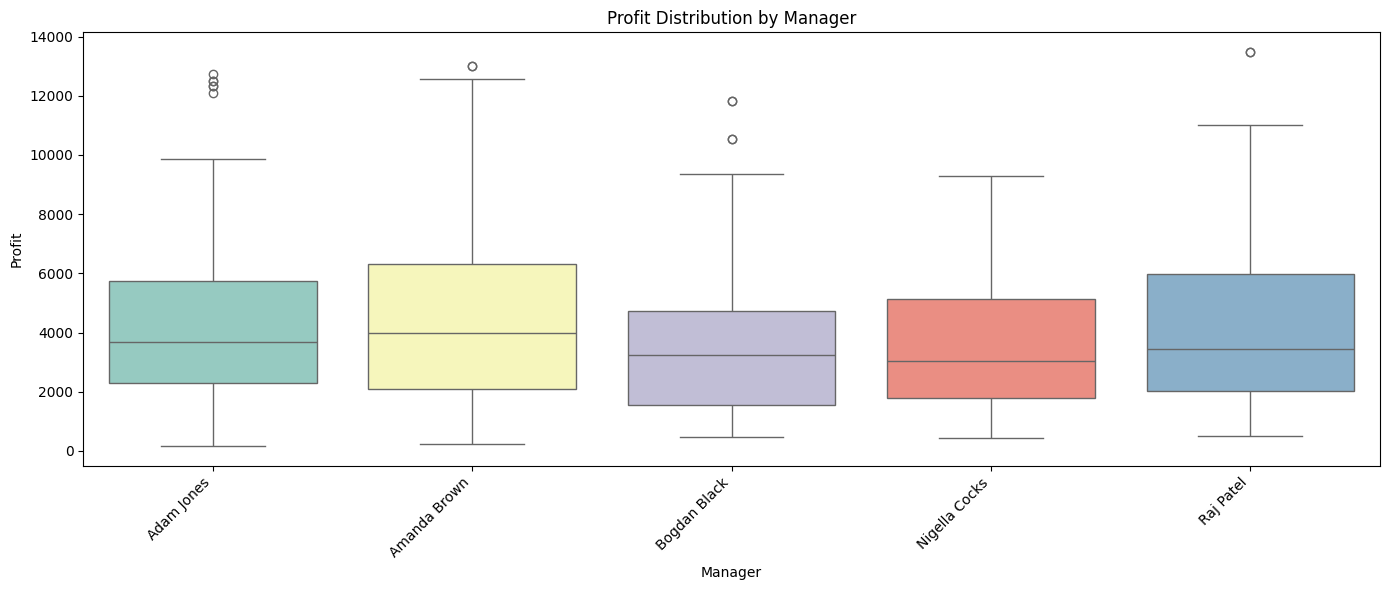

In [34]:

plt.figure(figsize=(14, 6))
fig_box = sns.boxplot(data=df, x='Manager', y='Profit', palette='Set3')
plt.title('Profit Distribution by Manager')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Manager')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

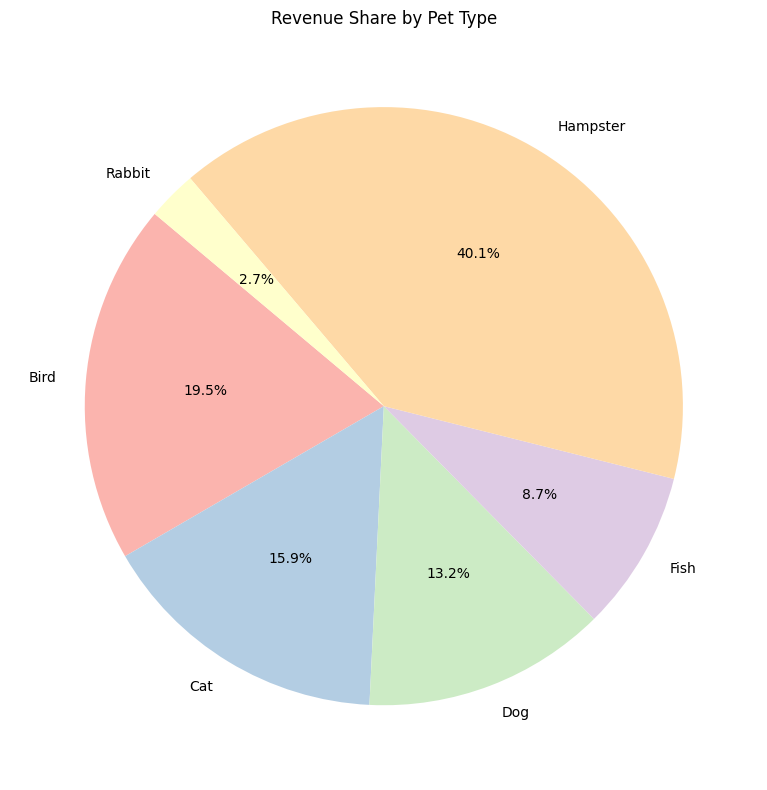

In [35]:
revenue_by_pet = df.groupby('Pet')['Revenue'].sum()

# Plot
fig_pie, ax = plt.subplots(figsize=(8, 8))
ax.pie(revenue_by_pet, labels=revenue_by_pet.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
ax.set_title('Revenue Share by Pet Type')
plt.tight_layout()
plt.show()

In [36]:
df_treemap = df.groupby(['Area', 'Pet']).agg(Total_Profit=('Profit', 'sum')).reset_index()

# Plot
fig_treemap = px.treemap(df_treemap, path=['Area', 'Pet'], values='Total_Profit',
                         color='Total_Profit', color_continuous_scale='RdBu',
                         title='Hierarchical Profit by Area and Pet Type')
fig_treemap

In [37]:
df_area = df.sort_values('Date')
df_area['Cumulative_Profit'] = df_area['Profit'].cumsum()

# Plot
fig_area = px.area(df_area, x='Date', y='Cumulative_Profit',
                   title='Cumulative Profit Over Time',
                   labels={'Cumulative_Profit': 'Cumulative Profit (£)', 'Date': 'Date'})
fig_area

In [38]:
df = df.sort_values('Date')
df['Cumulative Profit'] = df['Profit'].cumsum()

# Create the interactive line chart
import plotly.express as px

fig_cumulative = px.line(
    df,
    x='Date',
    y='Cumulative Profit',
    title='Cumulative Profit Over Time with Annotations',
    markers=True,  # Adds points you can hover/click
    hover_data=['Area', 'Pet', 'Profit', 'Revenue', 'Cost']
)

fig_cumulative.update_traces(mode="lines+markers")

fig_cumulative

In [39]:
fig_scatter3 = px.scatter(
    df,
    x='Units Sld',
    y='Profit',
    color='Pet',
    hover_data=['Manager', 'Date'],
    title='Units Sold vs. Profit by Pet Type'
)

fig_scatter3

In [40]:
fig_sunburst = px.sunburst(
    df,
    path=['Area', 'Pet', 'Manager'],
    values='Revenue',
    title='Hierarchical Revenue Breakdown (Area → Pet → Manager)'
)

fig_sunburst

In [41]:
sankey_df = df.groupby(['Area', 'Pet', 'Manager'])['Profit'].sum().reset_index()

# Create label list
labels = list(pd.unique(sankey_df['Area'].tolist() + sankey_df['Pet'].tolist() + sankey_df['Manager'].tolist()))
label_to_index = {label: idx for idx, label in enumerate(labels)}

# Create sources, targets, and values
sources = sankey_df['Area'].map(label_to_index)
targets = sankey_df['Pet'].map(label_to_index)
values = sankey_df['Profit']

# From Pet to Manager
sources = pd.concat([sources, sankey_df['Pet'].map(label_to_index)], ignore_index=True)
targets = pd.concat([targets, sankey_df['Manager'].map(label_to_index)], ignore_index=True)
values = pd.concat([values, sankey_df['Profit']], ignore_index=True)

# Sankey Diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    ))]
)

fig.update_layout(title_text="Sankey Diagram: Profit Flow", font_size=10)
fig.show()


In [42]:
df.columns

Index(['Managers First Name', 'Managers Surname', 'Area', 'Pet', 'Units Sld',
       'Revenue', 'Cost', 'Profit', 'Date', 'Manager', 'Price Per Unit',
       'Latitude', 'Longitude', 'Profit_Margin(%)', 'Cost Per Unit',
       'Profitability Flag', 'Month', 'Cumulative Profit'],
      dtype='object')

In [ ]:
df['YearMonth'] = df['Date'].dt.to_period('M').astype(str)
app = Dash(__name__)

# Define app layout
app.layout = html.Div([
    html.H1("Profit/Loss by Pet Type for All Locations Over Time"),
    dcc.Graph(id='animated-scatter', style={'height': '700px', 'width': '1200px'})
])

# Define the animated scatter plot
def create_animated_scatter():
    fig = px.scatter(
        df,
        x='Pet',
        y='Profit',
        animation_frame='YearMonth',  # Automatically animates through months
        color='Area',  # Differentiate by location
        size='Units Sld',
        title='Profit/Loss by Pet Type for All Locations',
        labels={'Profit': 'Profit (£)', 'Pet': 'Pet Type', 'Area': 'Location'},
        range_y=[df['Profit'].min() - 100, df['Profit'].max() + 100]
    )

    # Customize animation settings for auto-play and smooth transitions
    fig.update_layout(
        transition={'duration': 1000},  # 1-second transition between frames
        updatemenus=[
            {
                'buttons': [
                    {
                        'args': [None, {'frame': {'duration': 1000, 'redraw': True}, 'fromcurrent': True, 'mode': 'immediate'}],
                        'label': 'Play',
                        'method': 'animate'
                    },
                    {
                        'args': [[None], {'frame': {'duration': 0, 'redraw': True}, 'mode': 'immediate'}],
                        'label': 'Pause',
                        'method': 'animate'
                    }
                ],
                'direction': 'left',
                'pad': {'r': 10, 't': 87},
                'showactive': False,
                'type': 'buttons',
                'x': 0.1,
                'xanchor': 'right',
                'y': 0,
                'yanchor': 'top'
            }
        ]
    )

    return fig

# Assign the figure to the graph component
app.layout.children[-1].figure = create_animated_scatter()

# Run the app
if __name__ == '__main__':
    app.run(debug=True)

Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: on


In [ ]:
df['Profit Margin (%)'] = (df['Profit'] / df['Revenue']) * 100
df['Area-Pet Combination'] = df['Area'] + ' - ' + df['Pet']

# Initialize app
app = Dash(__name__)

# Layout
app.layout = html.Div([
    html.H1('Interactive Dashboard: Area and Pet Filters'),

    html.Div([
        dcc.Dropdown(
            id='area-filter',
            options=[{'label': area, 'value': area} for area in df['Area'].unique()],
            value=df['Area'].unique().tolist(),
            multi=True,
            placeholder="Select Area(s)"
        ),
        dcc.Dropdown(
            id='pet-filter',
            options=[{'label': pet, 'value': pet} for pet in df['Pet'].unique()],
            value=df['Pet'].unique().tolist(),
            multi=True,
            placeholder="Select Pet(s)"
        ),
    ], style={'width': '50%', 'display': 'inline-block'}),

    dcc.Graph(id='revenue-trend'),
    dcc.Graph(id='profit-margin-trend')
])

# Callbacks
@app.callback(
    [Output('revenue-trend', 'figure'),
     Output('profit-margin-trend', 'figure')],
    [Input('area-filter', 'value'),
     Input('pet-filter', 'value')]
)
def update_charts(selected_areas, selected_pets):
    filtered_df = df[(df['Area'].isin(selected_areas)) & (df['Pet'].isin(selected_pets))]

    fig_revenue = px.line(
        filtered_df,
        x='Date',
        y='Revenue',
        color='Area-Pet Combination',
        title='Revenue Trend by Area and Pet'
    )

    fig_profit_margin = px.line(
        filtered_df,
        x='Date',
        y='Profit Margin (%)',
        color='Area-Pet Combination',
        title='Profit Margin (%) Trend by Area and Pet'
    )

    return fig_revenue, fig_profit_margin

# Run app
app.run(debug=True)

In [ ]:
import pandas as pd
import plotly.express as px
from geopy.geocoders import Nominatim
import time
import folium
import plotly.graph_objects as go
from IPython.display import display, HTML, IFrame
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.subplots as sp
import dash
from dash import Dash, dcc, html
from dash.dependencies import Input, Output
import warnings

warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_excel('Fury_Friends data set_4376.xlsx')

# Check for missing values
df.isna().sum()
df.info()

# Define the columns you want unique values for
columns_of_interest = ["Managers First Name", "Managers Surname", "Area", "Pet"]

# Get unique values for selected columns
unique_values = {col: df[col].unique() for col in columns_of_interest}

# Print unique values
for col, values in unique_values.items():
    print(f"Unique values in '{col}': {values}\n")

# Group by Area to get unique managers
result = df.groupby('Area').agg({
    'Managers First Name': lambda x: x.unique().tolist(),
    'Managers Surname': lambda x: x.unique().tolist()
}).reset_index()

print(result)

# Fill the "Managers First Name" column
df["Managers First Name"] = (
    df.groupby("Area")["Managers First Name"]
      .transform(lambda x: x.fillna(x.dropna().unique()[0]))
)

# Fill the "Managers Surname" column
df["Managers Surname"] = (
    df.groupby("Area")["Managers Surname"]
      .transform(lambda x: x.fillna(x.dropna().unique()[0]))
)

# Verify filled manager names
result1 = df.groupby('Area').agg({
    'Managers First Name': lambda x: x.unique().tolist(),
    'Managers Surname': lambda x: x.unique().tolist()
}).reset_index()

result1

# Combine manager names to create a unique store identifier
df['Manager'] = df['Managers First Name'] + ' ' + df['Managers Surname']

# Fill 'Cost' where 'Revenue' and 'Profit' are available
mask_cost = df['Cost'].isna() & ~df['Revenue'].isna() & ~df['Profit'].isna()
df.loc[mask_cost, 'Cost'] = df.loc[mask_cost, 'Revenue'] - df.loc[mask_cost, 'Profit']

# Fill 'Profit' where 'Revenue' and 'Cost' are available
mask_profit = df['Profit'].isna() & ~df['Revenue'].isna() & ~df['Cost'].isna()
df.loc[mask_profit, 'Profit'] = df.loc[mask_profit, 'Revenue'] - df.loc[mask_profit, 'Cost']

# Fill remaining missing values with group medians
columns_to_fill = ['Cost', 'Profit', 'Revenue', 'Units Sld']
for col in columns_to_fill:
    # Calculate median within each 'Area' and 'Pet' group
    group_medians = df.groupby(['Area', 'Pet'])[col].transform('median')
    # Fill missing values with group medians
    df[col] = df[col].fillna(group_medians)
    # If group median is NaN (group has all NaN), use overall median
    overall_median = df[col].median()
    df[col].fillna(overall_median, inplace=True)

# Calculate 'Price Per Unit', handling division by zero
if (df['Units Sld'] == 0).any():
    print("Warning: 'Units Sld' contains zeros, which may cause division errors.")
    df['Units Sld'] = df['Units Sld'].replace(0, 1)  # Simplest fix
df['Price Per Unit'] = df['Revenue'] / df['Units Sld']

# Check for remaining missing values
df.isna().sum()

# Location coordinates
area_coords = {
    'Dudley': {'lat': 52.5107, 'lon': -2.0866},
    'Manchester': {'lat': 53.4808, 'lon': -2.2426},
    'Blackpool': {'lat': 53.8167, 'lon': -3.0370},
    'Glasgow': {'lat': 55.8617, 'lon': -4.2583},
    'Margate': {'lat': 51.3896, 'lon': 1.3868}
}
df['Latitude'] = df['Area'].map(lambda x: area_coords[x]['lat'])
df['Longitude'] = df['Area'].map(lambda x: area_coords[x]['lon'])

# Derived metrics
df['Profit_Margin(%)'] = df.apply(lambda row: row['Profit'] / row['Revenue']*100 if row['Revenue'] != 0 else 0, axis=1)
df['Cost Per Unit'] = df['Cost'] / df['Units Sld']
df['Profitability Flag'] = df['Profit'].apply(lambda x: 'Yes' if x > 0 else 'No')

# Choropleth Map
agg_df = df.groupby('Area').agg({
    'Profit': 'mean',
    'Latitude': 'first',
    'Longitude': 'first'
}).reset_index()

fig_map = px.scatter_geo(
    agg_df,
    lat='Latitude',
    lon='Longitude',
    color='Profit',
    size='Profit',
    hover_name='Area',
    title='Average Profit by Location',
    projection='natural earth',
    template='plotly_white',
    size_max=20
)
fig_map.update_geos(
    fitbounds="locations",
    showcountries=True,
    countrycolor="RebeccaPurple",
    showland=True,
    landcolor="lightgray",
    showocean=True,
    oceancolor="lightblue",
    lakecolor="lightblue",
    resolution=50
)
fig_map.update_layout(
    margin={"r":0, "t":50, "l":0, "b":0},
    title_font=dict(size=22, family='Arial', color='darkblue')
)
fig_map.show()

# Initialize the geolocator
geolocator = Nominatim(user_agent="my_geocoder_app")

# List of cities
cities = ['Margate', 'Manchester', 'Glasgow', 'Blackpool', 'Dudley']

# Empty dictionary to store city coordinates
city_coords = {}

# Loop through each city and get the coordinates
for city in cities:
    location = geolocator.geocode(city + ", UK")
    if location:
        city_coords[city] = {'Latitude': location.latitude, 'Longitude': location.longitude}
    else:
        city_coords[city] = {'Latitude': None, 'Longitude': None}
    time.sleep(1)  # Avoid rate limiting

# Display the coordinates
city_coords

# Add store markers with customized size based on revenue
m = folium.Map(location=[54.5260, 1.5260], zoom_start=6)
for idx, row in df.iterrows():
    if pd.notna(row['Latitude']) and pd.notna(row['Longitude']):
        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=row['Revenue'] / 5000,
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6,
            popup=f"Store: {row['Area']}<br>Revenue: £{row['Revenue']}",
        ).add_to(m)

# Save the updated map
map_filename = '/content/performance&size_map.html'
m.save(map_filename)

# Display map
m

# Map Visualization: Plot store locations using Latitude and Longitude, sizing by Profit
fig_map = px.scatter_geo(df,
                         lat='Latitude',
                         lon='Longitude',
                         hover_name='Manager',
                         size='Profit',
                         color='Area',
                         title='Store Locations and Profit',
                         projection='natural earth')
fig_map

# Bar Chart: Profit by Pet
fig_bar = px.bar(df.groupby('Pet')['Profit'].sum().reset_index(), x='Pet', y='Profit', color='Pet',
                 title='Total Profit by Pet Type')
fig_bar

# Stacked Bar: Profit by Pet and Location
fig_stack = px.bar(df.groupby(['Area', 'Pet'])['Profit'].sum().reset_index(), x='Area', y='Profit', color='Pet',
                   title='Profit by Pet Type and Location')
fig_stack

# Scatter Plot: Profit Margin by Pet type with Area as color category
fig_scatter = px.scatter(df, x='Pet', y='Profit_Margin(%)', color='Area',
                         title='Profit Margin by Pet Type',
                         labels={'Profit_Margin': 'Profit Margin'})
fig_scatter

# Line Chart: Monthly Profit
df['Month'] = df['Date'].dt.to_period('M').astype(str)
monthly_profit = df.groupby('Month')['Profit'].sum().reset_index()
fig_line = px.line(monthly_profit, x='Month', y='Profit', title='Monthly Profit Trend')
fig_line.update_traces(mode='lines+markers', marker=dict(symbol='circle', size=10))
fig_line

# Box Plot: Profit Distribution by Manager
plt.figure(figsize=(14, 6))
fig_box = sns.boxplot(data=df, x='Manager', y='Profit', palette='Set3')
plt.title('Profit Distribution by Manager')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Manager')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

# Pie Chart: Revenue Share by Pet Type
revenue_by_pet = df.groupby('Pet')['Revenue'].sum()
fig_pie, ax = plt.subplots(figsize=(8, 8))
ax.pie(revenue_by_pet, labels=revenue_by_pet.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
ax.set_title('Revenue Share by Pet Type')
plt.tight_layout()
plt.show()

# Treemap: Hierarchical Profit by Area and Pet Type
df_treemap = df.groupby(['Area', 'Pet']).agg(Total_Profit=('Profit', 'sum')).reset_index()
fig_treemap = px.treemap(df_treemap, path=['Area', 'Pet'], values='Total_Profit',
                         color='Total_Profit', color_continuous_scale='RdBu',
                         title='Hierarchical Profit by Area and Pet Type')
fig_treemap

# Area Chart: Cumulative Profit Over Time
df_area = df.sort_values('Date')
df_area['Cumulative_Profit'] = df_area['Profit'].cumsum()
fig_area = px.area(df_area, x='Date', y='Cumulative_Profit',
                   title='Cumulative Profit Over Time',
                   labels={'Cumulative_Profit': 'Cumulative Profit (£)', 'Date': 'Date'})
fig_area

# Line Chart: Cumulative Profit Over Time with Annotations
df = df.sort_values('Date')
df['Cumulative Profit'] = df['Profit'].cumsum()
fig_cumulative = px.line(
    df,
    x='Date',
    y='Cumulative Profit',
    title='Cumulative Profit Over Time with Annotations',
    markers=True,
    hover_data=['Area', 'Pet', 'Profit', 'Revenue', 'Cost']
)
fig_cumulative.update_traces(mode="lines+markers")
fig_cumulative

# Scatter Plot: Units Sold vs. Profit by Pet Type
fig_scatter3 = px.scatter(
    df,
    x='Units Sld',
    y='Profit',
    color='Pet',
    hover_data=['Manager', 'Date'],
    title='Units Sold vs. Profit by Pet Type'
)
fig_scatter3

# Sunburst Chart: Hierarchical Revenue Breakdown
fig_sunburst = px.sunburst(
    df,
    path=['Area', 'Pet', 'Manager'],
    values='Revenue',
    title='Hierarchical Revenue Breakdown (Area → Pet → Manager)'
)
fig_sunburst

# Sankey Diagram: Profit Flow
sankey_df = df.groupby(['Area', 'Pet', 'Manager'])['Profit'].sum().reset_index()
labels = list(pd.unique(sankey_df['Area'].tolist() + sankey_df['Pet'].tolist() + sankey_df['Manager'].tolist()))
label_to_index = {label: idx for idx, label in enumerate(labels)}
sources = sankey_df['Area'].map(label_to_index)
targets = sankey_df['Pet'].map(label_to_index)
values = sankey_df['Profit']
sources = pd.concat([sources, sankey_df['Pet'].map(label_to_index)], ignore_index=True)
targets = pd.concat([targets, sankey_df['Manager'].map(label_to_index)], ignore_index=True)
values = pd.concat([values, sankey_df['Profit']], ignore_index=True)
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    ))]
)
fig.update_layout(title_text="Sankey Diagram: Profit Flow", font_size=10)
fig.show()

# Dash App 1: Animated Scatter Plot
df['YearMonth'] = df['Date'].dt.to_period('M').astype(str)
app = Dash(__name__)

app.layout = html.Div([
    html.H1("Profit/Loss by Pet Type for All Locations Over Time"),
    dcc.Graph(id='animated-scatter', style={'height': '700px', 'width': '1200px'})
])

def create_animated_scatter():
    fig = px.scatter(
        df,
        x='Pet',
        y='Profit',
        animation_frame='YearMonth',
        color='Area',
        size='Units Sld',
        title='Profit/Loss by Pet Type for All Locations',
        labels={'Profit': 'Profit (£)', 'Pet': 'Pet Type', 'Area': 'Location'},
        range_y=[df['Profit'].min() - 100, df['Profit'].max() + 100]
    )
    fig.update_layout(
        transition={'duration': 1000},
        updatemenus=[
            {
                'buttons': [
                    {
                        'args': [None, {'frame': {'duration': 1000, 'redraw': True}, 'mode': 'immediate'}],
                        'label': 'Play',
                        'method': 'animate'
                    },
                    {
                        'args': [[None], {'frame': {'duration': 0, 'redraw': True}, 'mode': 'immediate'}],
                        'label': 'Pause',
                        'method': 'animate'
                    }
                ],
                'direction': 'left',
                'pad': {'r': 10, 't': 87},
                'showactive': False,
                'type': 'buttons',
                'x': 0.1,
                'xanchor': 'right',
                'y': 0,
                'yanchor': 'top'
            }
        ]
    )
    return fig

app.layout.children[-1].figure = create_animated_scatter()

if __name__ == '__main__':
    app.run(debug=True)

# Dash App 2: Interactive Dashboard with Area and Pet Filters
df['Profit Margin (%)'] = (df['Profit'] / df['Revenue']) * 100
df['Area-Pet Combination'] = df['Area'] + ' - ' + df['Pet']
app = Dash(__name__)

app.layout = html.Div([
    html.H1('Interactive Dashboard: Area and Pet Filters'),
    html.Div([
        dcc.Dropdown(
            id='area-filter',
            options=[{'label': area, 'value': area} for area in df['Area'].unique()],
            value=df['Area'].unique().tolist(),
            multi=True,
            placeholder="Select Area(s)"
        ),
        dcc.Dropdown(
            id='pet-filter',
            options=[{'label': pet, 'value': pet} for pet in df['Pet'].unique()],
            value=df['Pet'].unique().tolist(),
            multi=True,
            placeholder="Select Pet(s)"
        ),
    ], style={'width': '50%', 'display': 'inline-block'}),
    dcc.Graph(id='revenue-trend'),
    dcc.Graph(id='profit-margin-trend')
])

@app.callback(
    [Output('revenue-trend', 'figure'),
     Output('profit-margin-trend', 'figure')],
    [Input('area-filter', 'value'),
     Input('pet-filter', 'value')]
)
def update_charts(selected_areas, selected_pets):
    filtered_df = df[(df['Area'].isin(selected_areas)) & (df['Pet'].isin(selected_pets))]
    fig_revenue = px.line(
        filtered_df,
        x='Date',
        y='Revenue',
        color='Area-Pet Combination',
        title='Revenue Trend by Area and Pet'
    )
    fig_profit_margin = px.line(
        filtered_df,
        x='Date',
        y='Profit Margin (%)',
        color='Area-Pet Combination',
        title='Profit Margin (%) Trend by Area and Pet'
    )
    return fig_revenue, fig_profit_margin

app.run(debug=True)